# 実力差別の次の得点までの待ち時間（シーズン最終勝ち点の差）

両チームの実力差で、次に自分たちが点を取るまでの時間が変わるかを調べる。
実力差は、シーズン終了時の勝ち点の差で表す。

$$
\text{実力差} = \text{自チームの最終勝ち点} - \text{相手の最終勝ち点}
$$

実力差は7つに分ける。全試合のホーム・アウェイ両方の実力差を集め、それぞれの区分の数がだいたい同じになるように境目を決める（7分位）。

## データの作り方

試合をキックオフ・得点・試合終了で区切り、区間ごとにホームとアウェイの観測を1件ずつ作る。
実力差は試合中変わらないので、同じ試合の同じチームの観測はすべて同じ区分になる。

### 観測の終わり方
| 終わり方 | 内容 |
|---|---|
| イベント | 自チームが得点した |
| 打ち切り（相手の得点） | 先に相手が得点した（図では赤） |
| 打ち切り（試合終了） | 得点がないまま試合が終わった（図では青） |

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフの日本語が文字化けしないようにする
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# 図で使う色
CENSOR_OPPONENT_COLOR = "red"   # 相手の得点による打ち切り
CENSOR_MATCHEND_COLOR = "blue"  # 試合終了による打ち切り
MEDIAN_COLOR = "#009E73"        # 生存時間中央値の線


/Users/fujitaharukanin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. データの読み込み

`statsbomb_data` にある全リーグ・全シーズンの `*_goals_and_red_cards.csv` を読み込んで、1つの表にまとめる。

In [2]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 実力差の区分を決める

全試合のホーム・アウェイ両方の実力差を集め、`pd.qcut` で7分位に分けて境目を求める。

In [3]:
end_rows_for_bins = df_all[df_all["red_card"].isna() & df_all["home_away"].isna()
                            & df_all["end_time_minutes"].notna()].copy()
end_rows_for_bins["home_team_skill_gap"] = (
    end_rows_for_bins["home_final_points"] - end_rows_for_bins["away_final_points"]
)
end_rows_for_bins["away_team_skill_gap"] = -end_rows_for_bins["home_team_skill_gap"]

# 全試合のホーム・アウェイ両方の実力差を集める
pooled_skill_gap = pd.concat([
    end_rows_for_bins["home_team_skill_gap"],
    end_rows_for_bins["away_team_skill_gap"],
], ignore_index=True)

N_BINS = 7
_, SKILL_GAP_EDGES = pd.qcut(pooled_skill_gap, q=N_BINS, retbins=True)

# 区分の名前（境目を四捨五入する）
CATEGORY_ORDER = [
    f"{int(round(SKILL_GAP_EDGES[i]))}〜{int(round(SKILL_GAP_EDGES[i + 1]))}"
    for i in range(N_BINS)
]

# 両端を無限大にして、どの値もどこかの区分に入るようにする
CLASSIFY_EDGES = SKILL_GAP_EDGES.copy()
CLASSIFY_EDGES[0] = -np.inf
CLASSIFY_EDGES[-1] = np.inf

print(f"実力差7区分の境界（全チーム×全試合、n={len(pooled_skill_gap)} の実力差から算出）:")
for label in CATEGORY_ORDER:
    print(" -", label)


def classify_skill_gap(values):
    return pd.cut(values, bins=CLASSIFY_EDGES, labels=CATEGORY_ORDER, include_lowest=True)


実力差7区分の境界（全チーム×全試合、n=4922 の実力差から算出）:
 - -79〜-25
 - -25〜-12
 - -12〜-4
 - -4〜4
 - 4〜12
 - 12〜25
 - 25〜79


## 3. 生存時間データを作る

試合ごとに区間を作り、ホームとアウェイの観測を作る。区分は上で決めた実力差の区分を使う。

In [4]:
def build_survival_events(df):
    """試合ごとに区間を作り、区間ごとにホームとアウェイの観測を1件ずつ作る。
    区分は実力差で、試合中は変わらない
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)
    group_cols = ["league_code", "season_name", "match_id"]
    goal_groups = {key: g.sort_values("time_min") for key, g in goal_rows.groupby(group_cols)}

    # 試合終了の行（1試合に1行）
    end_rows = df[df["red_card"].isna() & df["home_away"].isna() & df["end_time_minutes"].notna()].copy()
    end_rows["full_time_min"] = end_rows["end_time_minutes"].astype(float) + end_rows["end_time_second"].astype(float) / 60.0
    end_rows["home_team_skill_gap"] = end_rows["home_final_points"] - end_rows["away_final_points"]
    end_rows["away_team_skill_gap"] = -end_rows["home_team_skill_gap"]
    end_rows["home_category"] = classify_skill_gap(end_rows["home_team_skill_gap"])
    end_rows["away_category"] = classify_skill_gap(end_rows["away_team_skill_gap"])

    records = []
    for row in end_rows.itertuples(index=False):
        key = (row.league_code, row.season_name, row.match_id)
        full_time = row.full_time_min
        cat_home = row.home_category
        cat_away = row.away_category
        meta = dict(league_code=row.league_code, season_name=row.season_name, match_id=row.match_id)

        g = goal_groups.get(key)
        if g is None:
            times = np.array([])
            sides = np.array([], dtype=int)
        else:
            times = g["time_min"].to_numpy()
            sides = g["home_away"].to_numpy()  # 0=home, 1=away

        prev_t = 0.0
        boundaries = list(times) + [full_time]
        for i, t in enumerate(boundaries):
            duration = t - prev_t
            is_last = (i == len(times))  # 最後の区間（試合終了で終わる）なら True

            if not is_last:
                scorer = int(sides[i])  # 得点した側（0=home, 1=away）
                if scorer == 0:
                    records.append({**meta, "team": "home", "category": cat_home,
                                     "waiting_time": duration, "event": 1, "censor_type": None})
                    records.append({**meta, "team": "away", "category": cat_away,
                                     "waiting_time": duration, "event": 0, "censor_type": "opponent"})
                else:
                    records.append({**meta, "team": "away", "category": cat_away,
                                     "waiting_time": duration, "event": 1, "censor_type": None})
                    records.append({**meta, "team": "home", "category": cat_home,
                                     "waiting_time": duration, "event": 0, "censor_type": "opponent"})
            else:
                records.append({**meta, "team": "home", "category": cat_home,
                                 "waiting_time": duration, "event": 0, "censor_type": "match_end"})
                records.append({**meta, "team": "away", "category": cat_away,
                                 "waiting_time": duration, "event": 0, "censor_type": "match_end"})

            prev_t = t

    return pd.DataFrame(records)


survival_df = build_survival_events(df_all)
n_event = int((survival_df["event"] == 1).sum())
n_cens_opp = int((survival_df["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df.groupby(["category", "event"], observed=True).size().unstack(fill_value=0).reindex(CATEGORY_ORDER)


観測数: 18850（イベント: 6964, 相手の得点による打ち切り: 6964, 試合終了による打ち切り: 4922）


event,0,1
category,,
-79〜-25,2619,468
-25〜-12,2067,653
-12〜-4,1665,774
-4〜4,1764,1007
4〜12,1342,953
12〜25,1315,1296
25〜79,1114,1813


## 4. ヒストグラムのビンを決める

待ち時間を5分刻みで数える。全部の図で同じビンを使う。

In [5]:
BIN_WIDTH = 5  # 分
max_wait = survival_df["waiting_time"].max()
BIN_EDGES = np.arange(0, np.ceil(max_wait / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait:.2f}分 -> ビン境界: 0〜{BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES)-1}ビン）")


最大待ち時間: 99.83分 -> ビン境界: 0〜100分（5分刻み、20ビン）


## 5. Kaplan-Meier曲線を当てはめる

`lifelines` の `KaplanMeierFitter` で、区分ごとにKaplan-Meier曲線を求める。
打ち切りがあると普通の中央値は使えないので、生存確率が0.5以下になる最初の時刻を「生存時間中央値」とする。

In [6]:
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
except ModuleNotFoundError:
    # lifelines がなければインストールする
    # インストールしたら、カーネルを再起動してから実行し直す
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )

km_fits = {}
km_summary_rows = []

for cat in CATEGORY_ORDER:
    sub = survival_df[survival_df["category"] == cat]
    n = len(sub)
    if n == 0:
        km_fits[cat] = None
        km_summary_rows.append({"実力差区分": cat, "n": 0, "イベント数": 0,
                                 "相手の得点による打ち切り": 0, "試合終了による打ち切り": 0,
                                 "生存時間中央値me(分)": np.nan})
        continue

    n_event = int((sub["event"] == 1).sum())
    n_cens_opp = int((sub["censor_type"] == "opponent").sum())
    n_cens_end = int((sub["censor_type"] == "match_end").sum())

    kmf = KaplanMeierFitter()
    kmf.fit(durations=sub["waiting_time"], event_observed=sub["event"], label=f"実力差={cat} (n={n})")
    km_fits[cat] = kmf

    km_summary_rows.append({"実力差区分": cat, "n": n, "イベント数": n_event,
                             "相手の得点による打ち切り": n_cens_opp, "試合終了による打ち切り": n_cens_end,
                             "生存時間中央値me(分)": kmf.median_survival_time_})

km_summary = pd.DataFrame(km_summary_rows).set_index("実力差区分").reindex(CATEGORY_ORDER)
km_summary


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
実力差区分,,,,,
-79〜-25,3087,468,1900,719,inf
-25〜-12,2720,653,1332,735,69.500000
-12〜-4,2439,774,987,678,54.750000
-4〜4,2771,1007,989,775,50.433333
4〜12,2295,953,711,631,43.316667
12〜25,2611,1296,606,709,35.383333
25〜79,2927,1813,439,675,24.133333


## 6. 待ち時間のヒストグラム

区分ごとに待ち時間のヒストグラムを描き、生存時間中央値の位置に点線を引く。

保存しました: ./figures/survival_final_point_gap_histograms.png


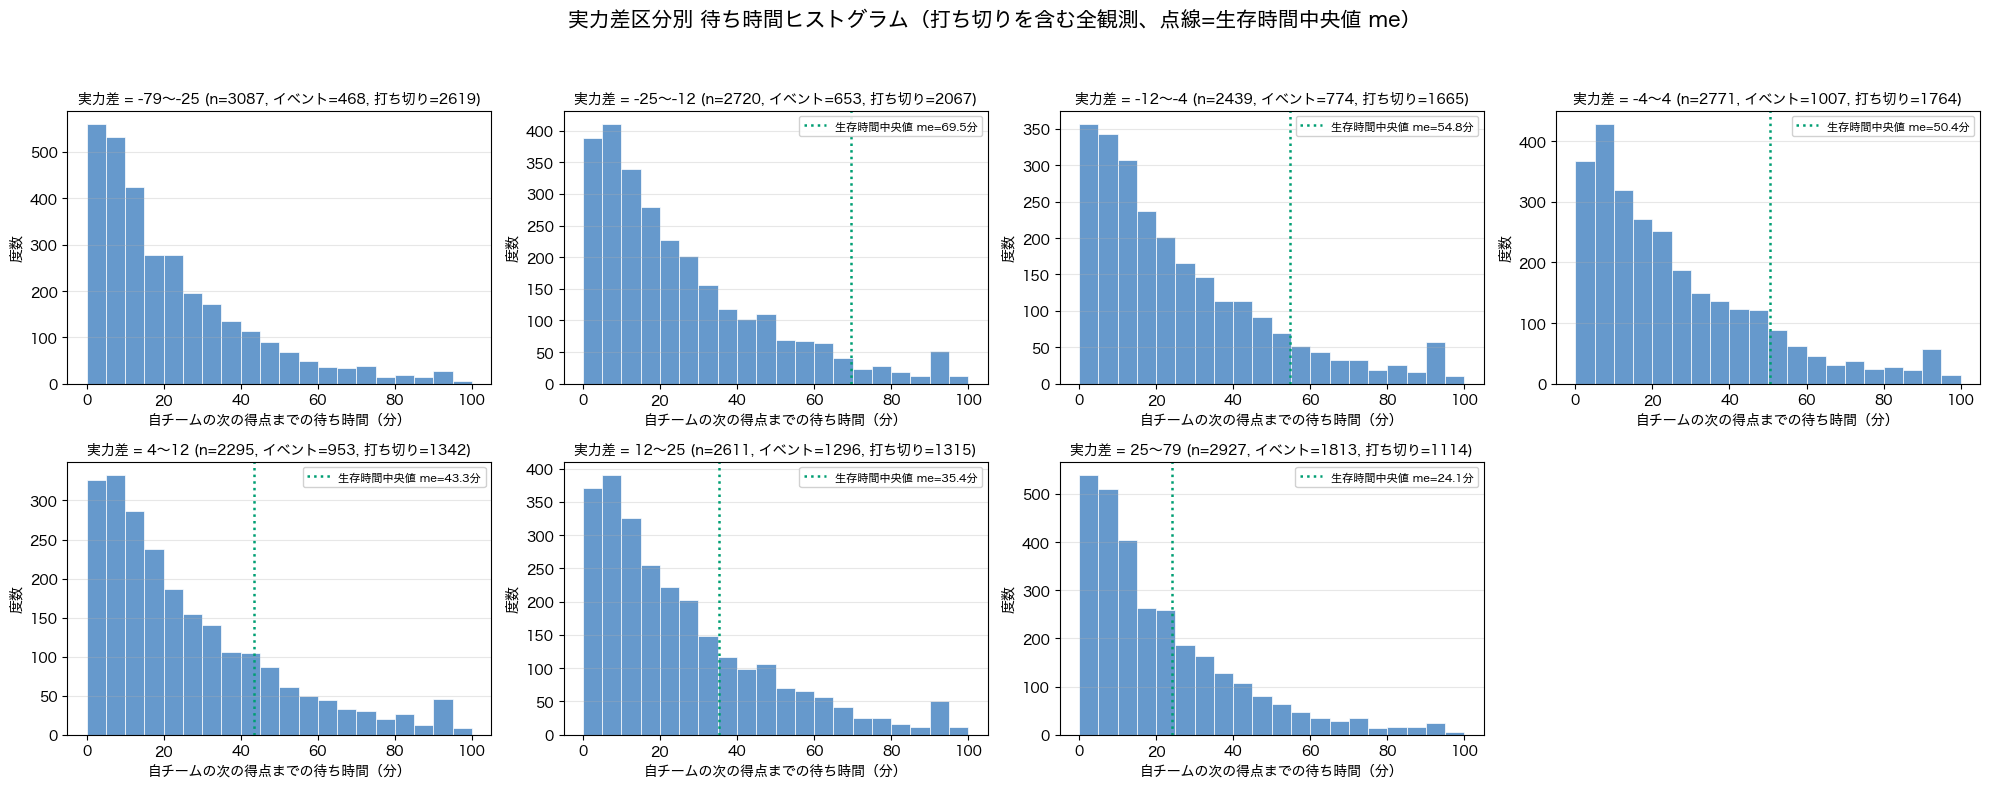

In [7]:
BAR_COLOR = "#6699CC"


def plot_hist_with_km_median(ax, sub_df, kmf, title, bin_edges, label_prefix="実力差"):
    vals = sub_df["waiting_time"].values
    n = len(vals)
    n_event = int((sub_df["event"] == 1).sum())
    n_cens = n - n_event

    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(bin_edges[:-1], counts, width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)

    if kmf is not None:
        me = kmf.median_survival_time_
        if np.isfinite(me):
            ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.8,
                        label=f"生存時間中央値 me={me:.1f}分")
            ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    ax.set_title(f"{label_prefix} = {title} (n={n}, イベント={n_event}, 打ち切り={n_cens})", fontsize=10)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    sub = survival_df[survival_df["category"] == cat]
    plot_hist_with_km_median(axes[i], sub, km_fits[cat], cat, BIN_EDGES)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

fig.suptitle("実力差区分別 待ち時間ヒストグラム（打ち切りを含む全観測、点線=生存時間中央値 me）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_final_point_gap_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 7. 区分ごとのKaplan-Meier曲線

区分ごとに1枚ずつ描く。打ち切りがあった時刻には短い縦線を入れる（赤：相手の得点、青：試合終了）。
生存確率0.5の線と、生存時間中央値も書き込む。

保存しました: ./figures/survival_final_point_gap_km_curves_grid.png


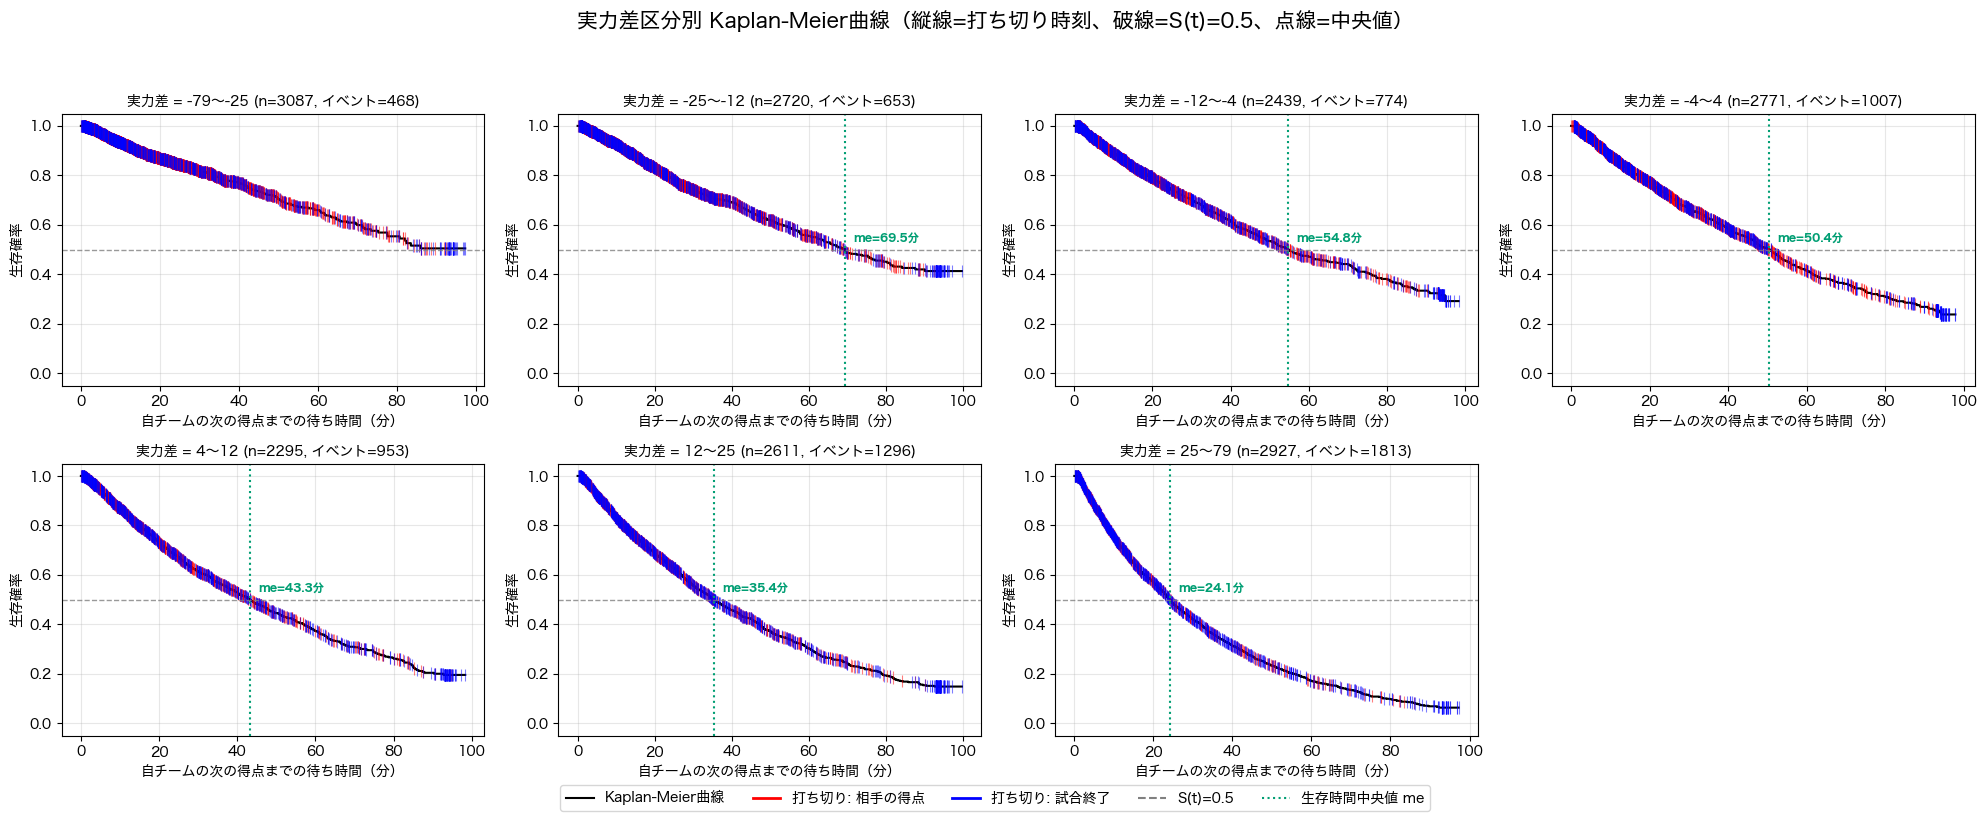

In [8]:
def plot_km_with_censor_marks(ax, sub_df, kmf, title, tick_height=0.025, label_prefix="実力差"):
    n = len(sub_df)
    n_event = int((sub_df["event"] == 1).sum())

    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False, legend=False,
                                color="black", linewidth=1.5)

    for censor_type, color in [("opponent", CENSOR_OPPONENT_COLOR), ("match_end", CENSOR_MATCHEND_COLOR)]:
        t_cens = sub_df.loc[sub_df["censor_type"] == censor_type, "waiting_time"].values
        if len(t_cens) == 0:
            continue
        s_vals = kmf.survival_function_at_times(t_cens).values
        ax.vlines(t_cens, s_vals - tick_height, s_vals + tick_height,
                   color=color, linewidth=0.8, alpha=0.5)

    # S(t)=0.5 の水平線
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    # 生存時間中央値の縦線と数字
    me = kmf.median_survival_time_
    if np.isfinite(me):
        ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.5)
        ax.annotate(f"me={me:.1f}分", xy=(me, 0.5), xytext=(6, 6),
                    textcoords="offset points", fontsize=8, color=MEDIAN_COLOR,
                    fontweight="bold")

    ax.set_title(f"{label_prefix} = {title} (n={n}, イベント={n_event})", fontsize=10)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    kmf = km_fits[cat]
    if kmf is None:
        axes[i].axis("off")
        continue
    sub = survival_df[survival_df["category"] == cat]
    plot_km_with_censor_marks(axes[i], sub, kmf, cat)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("実力差区分別 Kaplan-Meier曲線（縦線=打ち切り時刻、破線=S(t)=0.5、点線=中央値）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_final_point_gap_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


## 8. 7区分を重ねたKaplan-Meier曲線

7区分の曲線を1枚に重ねて比べる。

保存しました: ./figures/survival_final_point_gap_km_curves_overlay.png


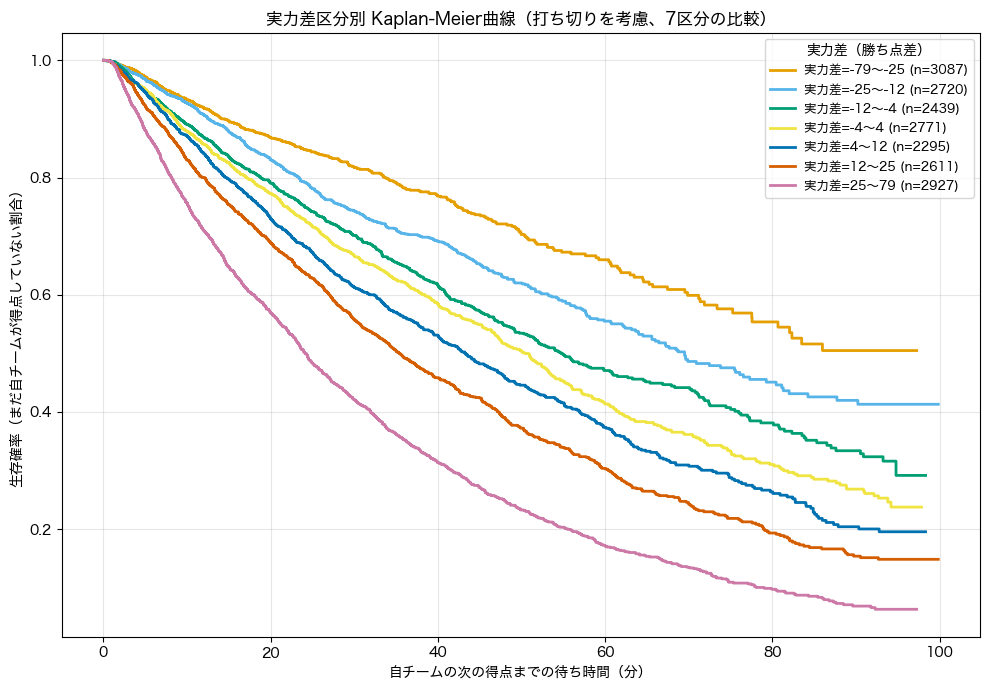

In [9]:
# 区分ごとの色
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, OKABE_ITO))

fig, ax = plt.subplots(figsize=(10, 7))

for cat in CATEGORY_ORDER:
    kmf = km_fits[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS[cat], linewidth=2)

ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ自チームが得点していない割合）")
ax.set_title("実力差区分別 Kaplan-Meier曲線（打ち切りを考慮、7区分の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="実力差（勝ち点差）")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_final_point_gap_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 9. ログランク検定

7区分をまとめて比べる検定と、2区分ずつ比べる検定（21通り）をする。
2区分ずつの比較は回数が多いので、Bonferroni補正したp値も出しておく。

In [10]:
# 7区分をまとめて比べる
overall_result = multivariate_logrank_test(
    event_durations=survival_df["waiting_time"],
    groups=survival_df["category"],
    event_observed=survival_df["event"],
)
print("=== 7区分一括のログランク検定（打ち切りを考慮） ===")
overall_result.print_summary()

# 2区分ずつ比べる（21通り）
pairwise_result = pairwise_logrank_test(
    event_durations=survival_df["waiting_time"],
    groups=survival_df["category"],
    event_observed=survival_df["event"],
)

pairwise_summary = pairwise_result.summary.copy()
n_comparisons = len(pairwise_summary)
pairwise_summary["p_bonferroni"] = (pairwise_summary["p"] * n_comparisons).clip(upper=1.0)
pairwise_summary = pairwise_summary.sort_values("p")

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# p値に星を付ける（例: 2.352009e-26***）
pairwise_summary["p"] = pairwise_summary["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
pairwise_summary["p_bonferroni"] = pairwise_summary["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")

print(f"\n=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数={n_comparisons}） ===")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")
pairwise_summary


=== 7区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=21） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


,,test_statistic,p,-log2(p),p_bonferroni
-79〜-25,25〜79,881.725870,9.213873e-194***,641.250243,1.934913e-192***
-25〜-12,25〜79,660.791756,1.004954e-145***,481.672444,2.110404e-144***
-12〜-4,25〜79,429.989333,1.633841e-95***,314.874901,3.431066e-94***
-79〜-25,12〜25,388.449836,1.800327e-86***,284.837557,3.780688e-85***
-4〜4,25〜79,370.432208,1.506916e-82***,271.806504,3.164524e-81***
-25〜-12,12〜25,235.987551,2.948688e-53***,174.502116,6.192244e-52***
-79〜-25,4〜12,224.791354,8.152993e-51***,166.391003,1.712128e-49***
25〜79,4〜12,221.634094,3.980631e-50***,164.103407,8.359326e-49***
-4〜4,-79〜-25,148.646325,3.426491e-34***,111.168823,7.195631e-33***
12〜25,25〜79,119.527550,8.027272e-28***,90.009077,1.685727e-26***
